In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
import gdown

In [5]:
gdown.download(f"https://drive.google.com/file/d/1oOqypOZxnpkbSLlO-X_Wu9RkFNrnW267", "/content/MICRODADOS_ENEM_2023.csv", quiet=False)
colunas = ['SG_UF_ESC', 'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH', 'TX_RESPOSTAS_LC',
       'TX_RESPOSTAS_MT', 'TP_LINGUA', 'TX_GABARITO_CN', 'TX_GABARITO_CH',
       'TX_GABARITO_LC', 'TX_GABARITO_MT', 'NU_NOTA_CN', 'NU_NOTA_CH',
           'NU_NOTA_LC', 'NU_NOTA_MT']
df_cresps = pd.read_parquet("https://drive.google.com/file/d/1oOqypOZxnpkbSLlO-X_Wu9RkFNrnW267")

/usr/local/lib/python3.11/dist-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://drive.google.com/file/d/1oOqypOZxnpkbSLlO-X_Wu9RkFNrnW267
To: /content/MICRODADOS_ENEM_2023.csv
94.5kB [00:00, 24.7MB/s]


ArrowInvalid: Could not open Parquet input source '<Buffer>': Parquet magic bytes not found in footer. Either the file is corrupted or this is not a parquet file.

In [ ]:
# df_cresps.columns

In [ ]:
df_cresps = df_cresps.dropna()
df_cresps = df_cresps.sample(n=5000).reset_index(drop=True)

NameError: name 'df_cresps' is not defined

In [ ]:
def calcular_acertos(respostas, gabarito):
    # Compara cada caractere das strings de respostas e gabarito
    return [1 if r == g else 0 for r, g in zip(respostas, gabarito)]

df_cresps['acertos CN'] = df_cresps.apply(lambda row: calcular_acertos(row['TX_RESPOSTAS_CN'], row['TX_GABARITO_CN']), axis=1)
df_cresps['acertos MT'] = df_cresps.apply(lambda row: calcular_acertos(row['TX_RESPOSTAS_MT'], row['TX_GABARITO_MT']), axis=1)
df_cresps['acertos CH'] = df_cresps.apply(lambda row: calcular_acertos(row['TX_RESPOSTAS_CH'], row['TX_GABARITO_CH']), axis=1)
df_cresps['acertos LC'] = df_cresps.apply(lambda row: calcular_acertos(row['TX_RESPOSTAS_LC'], row['TX_GABARITO_LC']), axis=1)

NameError: name 'df_cresps' is not defined

In [ ]:
def calcular_nota_por_acertos(acertos):
    return sum(acertos) / 45 * 1000

df_cresps['nota por acertos CN'] = df_cresps['acertos CN'].apply(calcular_nota_por_acertos)
df_cresps['nota por acertos MT'] = df_cresps['acertos MT'].apply(calcular_nota_por_acertos)
df_cresps['nota por acertos CH'] = df_cresps['acertos CH'].apply(calcular_nota_por_acertos)
df_cresps['nota por acertos LC'] = df_cresps['acertos LC'].apply(calcular_nota_por_acertos)

In [ ]:
df_cresps.head(10)

###Combinando os dataframes

In [ ]:
#montar o dataframe -> matriz com questões nas colunas e alunos nas linhas. vou considerar só 2023

In [ ]:
# df_gab = pd.read_parquet("/content/gabaritos.parquet")
# df_gab.columns

Index(['COR', 'ANO', 'COMPETENCIA', 'CO_PROVA', 'TX_GABARITO'], dtype='object')

In [ ]:
df_gab.head(5)

,COR,ANO,COMPETENCIA,CO_PROVA,TX_GABARITO
0,Azul,2019.0,CN,503,AAECACDEADCBCDDDBCBDADAEABCEBABEEBCBEECEBDADC
1,Amarelo,2019.0,CN,504,BEEAAEBEEBADEADDADAEABCEDDDBCBCBCCACBCDADCCEB
2,Branco,2019.0,CN,505,DADCCEBBCCACBEEBEEBACBCDDDDADBCBBCEAEADEADAAE
3,Rosa,2019.0,CN,506,DEADBAAAEBEECEBCBCBCBDADAEABCEDDDDADCBEECACBC
4,Azul,2019.0,CH,507,BACCCBABBADCBCEEEBCACACEEDBCCADBEADBADBBBACDB


In [ ]:
df_gab = df_gab[df_gab['ANO'] == 2023]

In [ ]:
#https://drive.google.com/file/d/15rEaadRHM5-J73zen32LZU8Mo7luW1Hk/view?usp=sharing - enems_subamostra
file_id = "15rEaadRHM5-J73zen32LZU8Mo7luW1Hk"
url = f"https://drive.google.com/uc?id={file_id}"
df_resp = pd.read_parquet(url)

In [ ]:
df_resp.head(5)

,NU_INSCRICAO,NU_ANO,TP_SEXO,TP_FAIXA_ETARIA,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,190001004651,2019,0,3,1,3,1,2,0,2,...,2.0,1.0,1.0,2.0,1.0,1.0,4.0,1.0,1.0,2.0
1,190001004662,2019,1,2,1,3,1,3,0,1,...,1.0,1.0,1.0,2.0,1.0,1.0,3.0,1.0,2.0,2.0
2,190001004736,2019,0,3,1,3,2,2,0,2,...,1.0,1.0,1.0,2.0,1.0,1.0,4.0,1.0,1.0,1.0
3,190001004926,2019,0,12,1,2,1,1,13,1,...,2.0,1.0,1.0,2.0,1.0,1.0,3.0,1.0,1.0,1.0
4,190001005145,2019,1,11,2,3,1,1,12,1,...,1.0,1.0,1.0,2.0,2.0,1.0,3.0,1.0,2.0,2.0


In [ ]:
df_resp.columns

Index(['NU_INSCRICAO', 'NU_ANO', 'TP_SEXO', 'TP_FAIXA_ETARIA',
       'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO',
       'TP_ANO_CONCLUIU', 'TP_ESCOLA', 'TP_ENSINO', 'IN_TREINEIRO',
       'CO_MUNICIPIO_ESC', 'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC',
       'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC', 'TP_PRESENCA_CN',
       'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'CO_PROVA_CN',
       'CO_PROVA_CH', 'CO_PROVA_LC', 'CO_PROVA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH',
       'NU_NOTA_LC', 'NU_NOTA_MT', 'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH',
       'TX_RESPOSTAS_LC', 'TX_RESPOSTAS_MT', 'TP_LINGUA', 'TP_STATUS_REDACAO',
       'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4',
       'NU_NOTA_COMP5', 'NU_NOTA_REDACAO', 'Q001', 'Q002', 'Q003', 'Q004',
       'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013',
       'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019', 'Q020', 'Q021', 'Q022',
       'Q023', 'Q024', 'Q025'],
      dty

In [ ]:
df_resp = df_resp[df_resp['NU_ANO'] == 2023]

In [ ]:
df_gab.shape

(16, 5)

In [ ]:
df_resp.shape

(60000, 66)

In [ ]:
df = pd.read_csv('/content/arq.csv')

In [ ]:
df.head(5)

,acertos CN,acertos MT,acertos CH,acertos LC
0,"[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, ...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, ...","[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, ..."
2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...","[1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, ...","[1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, ...","[1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, ...","[1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, ..."
4,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, ...","[1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...","[0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, ..."


In [ ]:
from ast import literal_eval
df['acertos CN'] = df['acertos CN'].apply(literal_eval)
df = np.array(df['acertos CN'].tolist())

In [ ]:
print(df.shape)
print(df[0])
print(df[:, 0])

(5000, 45)
[0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 0]
[0 1 0 ... 0 1 1]


In [ ]:
#enquanto eu não consigo esse caralho
# np.random.seed(25)  # para reprodutibilidade
# df = np.random.choice([0, 1], size=(2000, 45), p=[1 - 0.2, 0.2])

###pré-processamento

In [ ]:
# Importar Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Visualização das Colunas
pd.set_option('display.max_columns', None)

In [ ]:
#https://drive.google.com/file/d/15rEaadRHM5-J73zen32LZU8Mo7luW1Hk/view?usp=sharing - enems_subamostra
file_id = "15rEaadRHM5-J73zen32LZU8Mo7luW1Hk"
url = f"https://drive.google.com/uc?id={file_id}"
df_original = pd.read_parquet(url)

In [ ]:
df_original.shape

(300000, 66)

In [ ]:
df_original.columns

Index(['NU_INSCRICAO', 'NU_ANO', 'TP_SEXO', 'TP_FAIXA_ETARIA',
       'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO',
       'TP_ANO_CONCLUIU', 'TP_ESCOLA', 'TP_ENSINO', 'IN_TREINEIRO',
       'CO_MUNICIPIO_ESC', 'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC',
       'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC', 'TP_PRESENCA_CN',
       'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'CO_PROVA_CN',
       'CO_PROVA_CH', 'CO_PROVA_LC', 'CO_PROVA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH',
       'NU_NOTA_LC', 'NU_NOTA_MT', 'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH',
       'TX_RESPOSTAS_LC', 'TX_RESPOSTAS_MT', 'TP_LINGUA', 'TP_STATUS_REDACAO',
       'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4',
       'NU_NOTA_COMP5', 'NU_NOTA_REDACAO', 'Q001', 'Q002', 'Q003', 'Q004',
       'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013',
       'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019', 'Q020', 'Q021', 'Q022',
       'Q023', 'Q024', 'Q025'],
      dty

In [ ]:
columns = ['NU_INSCRICAO', 'NU_ANO', 'CO_PROVA_MT','TP_PRESENCA_LC', 'TP_PRESENCA_CN',
          'NU_NOTA_LC', 'NU_NOTA_CH', 'NU_NOTA_CN', 'NU_NOTA_MT','TP_LINGUA']

In [ ]:
df_original = df_original[columns]

In [ ]:
#https://drive.google.com/file/d/1Z1QxhTieDG3v9l_yfMskh_8dteuFavr3/view?usp=sharing - enems subamostra mapeado
file_id = "1Z1QxhTieDG3v9l_yfMskh_8dteuFavr3"
url = f"https://drive.google.com/uc?id={file_id}"
df_map = pd.read_parquet(url)

In [ ]:
df_original = df_original.merge(df_map, on='NU_INSCRICAO')
df_original

,NU_INSCRICAO,NU_ANO,CO_PROVA_MT,TP_PRESENCA_LC,TP_PRESENCA_CN,NU_NOTA_LC,NU_NOTA_CH,NU_NOTA_CN,NU_NOTA_MT,TP_LINGUA,TX_RESPOSTAS_CN_AZUL,TX_RESPOSTAS_CH_AZUL,TX_RESPOSTAS_LC_AZUL,TX_RESPOSTAS_MT_AZUL
0,190001004651,2019,518.0,1,1,485.1,417.2,412.5,446.2,1,ADDDDBDDDDDCEDACCEDBEEBDBBEEDABADAEEECBECACAB,ACBCABACAABBDCDCBCDADABADABDACCCBCAECDDEEBCCB,99999BCEBBDCBDEBDDCAAEDEBEDBECCDEDEAEBAACDAEBB...,CEDDDDBCBBDCBDECCAACCEAAAEBABABCEBDACDDCBABEB
1,190001004662,2019,515.0,1,1,478.5,492.8,511.9,432.8,1,EDECACDDEDBEADEADBCAEBADAACEDCAEEDEBDCBADBBCA,CCDCDBCACBDBEAAAEECDCBCBBDDEBDBDAAEBBABAECCCB,99999EBABDBDBBDDBACCBADEBDCCECEACCAAABDEADDEBA...,BEDBADCCBECDBDDBACACABBAABDEBADD*EDBDCECBDCAB
2,190001004736,2019,517.0,1,1,574.2,570.9,465.0,614.0,0,DEECDEDBCCBDACBABEDAADCDBBEEAEABBDDCACCEBDABA,BCECABCACBECADEAEBCBCADCEABEEADBAADAABBDEAADE,BECDE99999CCBAABADEBDAAECADECCECECCCEBDABDADBC...,ECEBDBCBDBAABDEACEAEDADACEADBAECECEAACECAEADB
3,190001004926,2019,515.0,1,1,443.4,487.1,404.6,388.6,1,CEDDDEDAEDDEADBAAEAEAEDDCDAEEDDBCBEBECBCABDDC,EECCACABBBEBBBCCEDDEEAEAADABBABBBEBECBBAEACDE,99999CBABDBAEDDAAADBAADEABECEEBCCBCECCDABEBDBA...,DCACBEDCABBDAAEEDDAEAEECAECECCBEEECAADEECBADE
4,190001005145,2019,517.0,1,1,507.7,485.6,555.6,472.0,0,CEECACDEABCEEBBCDAEAAADEABDECDADEDEBDABCDDB*E,BEBCEBACCBADCADAEECDAAECBEDECACCAEBDAEABABEEB,BDABE99999DCDEDCCEEEEAAEAADEECDAACCEABDDDDEEDA...,EDACEEBCABCDEBEACDBEDEEBBDEEABDCEEBCDDCCABCAB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,210062061543,2023,1211.0,1,1,547.0,464.0,530.2,430.9,0,DBDBCCEBCAEDDABBCBEBEDCAEDDBCBBDCDABDCBDAEBEA,CEEDDBAEACCACBAEBADEADBDACBEABDDCDBEACDAAACDA,BCCAA99999DBCACDBCDBADEDCDABEDEABDABBBCAABBCDB...,BDEDBBBCEDDAAADBDCADAACCEDCDDBABCABDCEBAEDBDC
299996,210062061582,2023,1214.0,1,1,541.9,545.1,560.9,457.9,0,EBEEDDECCABECEBAEBDCABBAACDEBBAABBECCCBDACBEB,CACCBAABDCCBAADECDDBABCDDABABCDBCAEAACBBABEDA,BBBAC99999DABEEDDC.CAACDDAAAEBCBBEAEBABAACAEBB...,CDACBBCDDCBBBCACBEDAAEBEECDDDCDECDCBEBDDBDACD
299997,210062061596,2023,1212.0,1,1,487.6,452.0,337.7,425.2,0,CCBEEBCBCABDEEDBECACEABCABBEAAEEBECDDDDBADEDD,CAAEEEDCDCACAADEEECDADEEDDCBBCACCDBAAEDECBCAA,BAEDB99999CAAAEDABABBDCDEDCBBCBDDBEDDEBADDDACC...,DCBAACDCCDCBEDABDBECDCEAEAEDEBAEACDBACEEACACD
299998,210062061746,2023,NaN,0,0,NaN,NaN,NaN,NaN,0,None,None,None,None


In [ ]:
#https://docs.google.com/spreadsheets/d/12V18kl-6wAnahjY7XNv64rrDOWBt9Hw5qJOPu8e7Cog/edit?usp=sharing
# file_id = "12V18kl-6wAnahjY7XNv64rrDOWBt9Hw5qJOPu8e7Cog"
# url = f"https://drive.google.com/uc?id={file_id}"
# df_codigos_gabaritos = pd.read_excel(url)

In [ ]:
df_codigos_gabaritos = pd.read_csv("/content/Corresp_quest_ENEM - GABARITO PROVAS.csv")

In [ ]:
df_codigos_gabaritos

,cor,ano,prova,codigo,gabarito
0,Azul,2019.0,CN,503,AAECACDEADCBCDDDBCBDADAEABCEBABEEBCBEECEBDADC
1,Amarelo,2019.0,CN,504,BEEAAEBEEBADEADDADAEABCEDDDBCBCBCCACBCDADCCEB
2,Branco,2019.0,CN,505,DADCCEBBCCACBEEBEEBACBCDDDDADBCBBCEAEADEADAAE
3,Rosa,2019.0,CN,506,DEADBAAAEBEECEBCBCBCBDADAEABCEDDDDADCBEECACBC
4,Azul,2019.0,CH,507,BACCCBABBADCBCEEEBCACACEEDBCCADBEADBADBBBACDB
...,...,...,...,...,...
255,NaN,NaN,NaN,1294,CEBDEABDEDEBAABEECBABADDBEDCCCDDBEECCDBAADDAC
256,NaN,NaN,NaN,1301,CBABDBCEEADDDBBCCBEBEEDDCCDCDEEACCBACEACACCDA
257,NaN,NaN,NaN,1302,BBCDCDBACCACCDAEEAEACCBAEDDCCBDBEACCCEDDDBEBE
258,NaN,NaN,NaN,1303,BDBEACECBABBCDDDBEBEACCDABACEACEEACCDCDEDDCCC


In [ ]:
df_original = df_original.rename(columns = {
                                'NU_INSCRICAO': 'nu_inscricao', 'NU_ANO': 'ano',
                                'TP_PRESENCA_LC': 'presenca_d1', 'TP_PRESENCA_CN': 'presenca_d2',
                                'NU_NOTA_LC': 'tri_lc', 'NU_NOTA_CH': 'tri_ch', 'NU_NOTA_CN': 'tri_cn', 'NU_NOTA_MT': 'tri_mt',
                                'TP_LINGUA': 'lingua',
                                'TX_RESPOSTAS_LC_AZUL': 'respostas_lc', 'TX_RESPOSTAS_CH_AZUL': 'respostas_ch', 'TX_RESPOSTAS_CN_AZUL': 'respostas_cn', 'TX_RESPOSTAS_MT_AZUL': 'respostas_mt'
                                })

In [ ]:
df = df_original.copy()

In [ ]:
df.head(3)

,nu_inscricao,ano,CO_PROVA_MT,presenca_d1,presenca_d2,tri_lc,tri_ch,tri_cn,tri_mt,lingua,respostas_cn,respostas_ch,respostas_lc,respostas_mt
0,190001004651,2019,518.0,1,1,485.1,417.2,412.5,446.2,1,ADDDDBDDDDDCEDACCEDBEEBDBBEEDABADAEEECBECACAB,ACBCABACAABBDCDCBCDADABADABDACCCBCAECDDEEBCCB,99999BCEBBDCBDEBDDCAAEDEBEDBECCDEDEAEBAACDAEBB...,CEDDDDBCBBDCBDECCAACCEAAAEBABABCEBDACDDCBABEB
1,190001004662,2019,515.0,1,1,478.5,492.8,511.9,432.8,1,EDECACDDEDBEADEADBCAEBADAACEDCAEEDEBDCBADBBCA,CCDCDBCACBDBEAAAEECDCBCBBDDEBDBDAAEBBABAECCCB,99999EBABDBDBBDDBACCBADEBDCCECEACCAAABDEADDEBA...,BEDBADCCBECDBDDBACACABBAABDEBADD*EDBDCECBDCAB
2,190001004736,2019,517.0,1,1,574.2,570.9,465.0,614.0,0,DEECDEDBCCBDACBABEDAADCDBBEEAEABBDDCACCEBDABA,BCECABCACBECADEAEBCBCADCEABEEADBAADAABBDEAADE,BECDE99999CCBAABADEBDAAECADECCECECCCEBDABDADBC...,ECEBDBCBDBAABDEACEAEDADACEADBAECECEAACECAEADB


In [ ]:
df[(df['presenca_d1'] == 1) & (df['presenca_d2'] == 1) & (df['ano'] == 2022) & (df['respostas_mt'] != 'nan')]['CO_PROVA_MT'].unique()

array([1076., 1078., 1075., 1077., 1185., 1083., 1186., 1183., 1184.,
       1158., 1157., 1156., 1155., 1082.])

In [ ]:
# Ano: 2023
df = df[df['ano'] == 2023]
df = df.drop(columns = ['ano'], errors = 'ignore')

In [ ]:
# Concluintes da prova toda
df = df[(df['presenca_d1'] == 1) & (df['presenca_d2'] == 1)]
df = df.drop(columns = ['presenca_d1', 'presenca_d2'], errors = 'ignore')

In [ ]:
# Todos receberam notas
print(df[df[['tri_lc', 'tri_ch', 'tri_cn', 'tri_mt']].isna().any(axis=1)])

Empty DataFrame
Columns: [nu_inscricao, CO_PROVA_MT, tri_lc, tri_ch, tri_cn, tri_mt, lingua, respostas_cn, respostas_ch, respostas_lc, respostas_mt]
Index: []


In [ ]:
df = df.dropna(subset=['respostas_cn', 'respostas_ch', 'respostas_lc', 'respostas_mt'])
df['CO_PROVA_MT'].unique()

array([1076., 1078., 1075., 1077.])

In [ ]:
# Gabaritos simples conforme a prova azul 2023
gabarito_ch = df_codigos_gabaritos[(df_codigos_gabaritos['cor'] == 'Azul') &
                                   (df_codigos_gabaritos['ano'] == 2023) &
                                   (df_codigos_gabaritos['prova'] == 'CH')]['gabarito'].iloc[0]

gabarito_cn = df_codigos_gabaritos[(df_codigos_gabaritos['cor'] == 'Azul') &
                                   (df_codigos_gabaritos['ano'] == 2023) &
                                   (df_codigos_gabaritos['prova'] == 'CN')]['gabarito'].iloc[0]

gabarito_mt = df_codigos_gabaritos[(df_codigos_gabaritos['cor'] == 'Azul') &
                                   (df_codigos_gabaritos['ano'] == 2023) &
                                   (df_codigos_gabaritos['prova'] == 'MT')]['gabarito'].iloc[0]

In [ ]:
# Filtrando os gabaritos para inglês e espanhol
gabarito_lc = df_codigos_gabaritos[(df_codigos_gabaritos['cor'] == 'Azul') &
                                   (df_codigos_gabaritos['ano'] == 2023) &
                                   (df_codigos_gabaritos['prova'] == 'LC')]['gabarito'].iloc[0]

gabarito_lc_ingles = gabarito_lc[0:5] + gabarito_lc[10:]
gabarito_lc_espanhol = gabarito_lc[5:]

In [ ]:
# Função para comparar respostas e gabarito gerando um vetor de 0s e 1s
def compare_respostas(respostas, gabarito):
    return np.array([1 if r == g else 0 for r, g in zip(respostas, gabarito)])

In [ ]:
df_respostas = df.copy()

In [ ]:
# Comparando e criando as novas colunas de acertos
df_respostas['acertos_lc'] = df_respostas.apply(
    lambda row: compare_respostas(row['respostas_lc'], gabarito_lc_ingles if row['lingua'] == 0 else gabarito_lc_espanhol),
    axis=1
)

df_respostas['acertos_ch'] = df_respostas['respostas_ch'].apply(
    lambda x: compare_respostas(x, gabarito_ch)
)

df_respostas['acertos_cn'] = df_respostas['respostas_cn'].apply(
    lambda x: compare_respostas(x, gabarito_cn)
)

df_respostas['acertos_mt'] = df_respostas['respostas_mt'].apply(
    lambda x: compare_respostas(x, gabarito_mt)
)

# Convertendo o vetor binário para um número
df_respostas['acertos_lc'] = df_respostas['acertos_lc'].apply(lambda x: ''.join(map(str, x)))
df_respostas['acertos_ch'] = df_respostas['acertos_ch'].apply(lambda x: ''.join(map(str, x)))
df_respostas['acertos_cn'] = df_respostas['acertos_cn'].apply(lambda x: ''.join(map(str, x)))
df_respostas['acertos_mt'] = df_respostas['acertos_mt'].apply(lambda x: ''.join(map(str, x)))

# Exibindo o DataFrame com as novas colunas
df_respostas.head()

,nu_inscricao,CO_PROVA_MT,tri_lc,tri_ch,tri_cn,tri_mt,lingua,respostas_cn,respostas_ch,respostas_lc,respostas_mt,acertos_lc,acertos_ch,acertos_cn,acertos_mt
180000,210054478298,1076.0,517.5,555.5,444.3,664.8,0,EBACDBDBEDABDEDDEABEEADECACCBEDACBBCCAEDECDBA,DEACEEDABDADDCCEBDEBACCDAADBBDCEDCADDBEDACDEA,CBDCE99999ECBACADDDBCBECBEEAECCDBEACEDDBDAEAED...,BADCDBABAECDAEACCCABEDDECBCABEEDCDBABDDEEABBB,000010000000100000000010000001000001000000101,111011110010010100010000111100000001010100001,000010000000010000000010001101010100010000100,001000000100000111010000001010001011111101010
180002,210054478363,1078.0,655.4,616.8,583.7,664.3,1,AEBBBCEAACDBDEADDBEDEBDECBECCBCAEEABAAECCCABA,AEABEDDBDDADDCBEBABBCDDEAAEBCECACACEBBCDABBCA,99999EDCAAEBAACABBDBEAACCBEEECCBBCEEEADBBAEAAB...,ADCDEBECCEDDABEDEEBBECEEADCBBCAACDDAADAEEACBB,000001001001000010000000100001000000000010100,011110100010011100011110110111010110111101011,101000001000011001010010010100011001010110000,000000001100010000010000101010111001010101010
180003,210054478391,1075.0,351.0,493.9,386.2,453.7,1,EBECBBABACCBAABBEBBACAABBABEBBAEDBAABCAADBEBD,DBAEADAAADBBEABBACABEAAAAAEBBDCAAADCEDCEACAAB,99999BBDAAEAADACAACABCCCEEBCEBEAEECBBBAAADBADA...,CBECACAEBBBEDBEBECABDDCEBCBACCCBDCEADABEBBDBD,000000001000010001101000001000010010010001000,101000010000101000110001110100010100001000000,000000001010000001000000100000000100000000000,000000000000110001010010000000000001000100010
180004,210054478410,1077.0,469.2,433.4,451.8,354.3,1,AECDBEECABEDCBDCEBCEAAECDACECCCAABBCCBEDACCDB,EBACACEADADDECECCACCADEBAEAAABDAAEADCABAACADA,99999BDEAECCCACADBDEBCCBEAA*CCCCCAAABEDBCDDADB...,CACEDDBEADCDCCEBDDDCAAEAEBEBBCEEACEDAADABEBBD,000000001000000000001000000001000000000001000,001000010000110010000100100000110001000000001,100000001100000101001001001000010100000000010,000000100000000000000000000010000000001000010
180006,210054478509,1077.0,549.9,557.8,551.5,651.1,0,BAACAEDDCCABEBCEEDAEABAECAECBDAACBBCBECCCDBCE,ACACEEDEEEBDDCBECBABCDEAAEEEDBDDAAEDBECDEACCA,CBBEA99999EBEAAADADEABACBEEBECCBBEAACADACADCDB...,DDCCDADCCDCCECBACBBEBCCCADCABDCECEBAEDAECDCBE,001000000001000001000000000101000000000000010,001011101000011111111101100000100101101100011,000000000000100000001000000100010100001111001,000000001001000010000010101010001111010100011


In [ ]:
df_respostas = df_respostas.drop(columns = ['respostas_lc', 'respostas_ch', 'respostas_cn', 'respostas_mt'], errors = 'ignore')

In [ ]:
# Contando o número de 1s em cada coluna de acertos
df_respostas['pontos_lc'] = df_respostas['acertos_lc'].str.count('1')
df_respostas['pontos_ch'] = df_respostas['acertos_ch'].str.count('1')
df_respostas['pontos_cn'] = df_respostas['acertos_cn'].str.count('1')
df_respostas['pontos_mt'] = df_respostas['acertos_mt'].str.count('1')

df_respostas['pontos_prova'] = df_respostas['pontos_lc'] + df_respostas['pontos_ch'] + df_respostas['pontos_cn'] + df_respostas['pontos_mt']

In [ ]:
df_respostas.head()

,nu_inscricao,CO_PROVA_MT,tri_lc,tri_ch,tri_cn,tri_mt,lingua,acertos_lc,acertos_ch,acertos_cn,acertos_mt,pontos_lc,pontos_ch,pontos_cn,pontos_mt,pontos_prova
180000,210054478298,1076.0,517.5,555.5,444.3,664.8,0,000010000000100000000010000001000001000000101,111011110010010100010000111100000001010100001,000010000000010000000010001101010100010000100,001000000100000111010000001010001011111101010,7,19,10,17,53
180002,210054478363,1078.0,655.4,616.8,583.7,664.3,1,000001001001000010000000100001000000000010100,011110100010011100011110110111010110111101011,101000001000011001010010010100011001010110000,000000001100010000010000101010111001010101010,8,28,16,15,67
180003,210054478391,1075.0,351.0,493.9,386.2,453.7,1,000000001000010001101000001000010010010001000,101000010000101000110001110100010100001000000,000000001010000001000000100000000100000000000,000000000000110001010010000000000001000100010,10,14,5,8,37
180004,210054478410,1077.0,469.2,433.4,451.8,354.3,1,000000001000000000001000000001000000000001000,001000010000110010000100100000110001000000001,100000001100000101001001001000010100000000010,000000100000000000000000000010000000001000010,4,11,11,4,30
180006,210054478509,1077.0,549.9,557.8,551.5,651.1,0,001000000001000001000000000101000000000000010,001011101000011111111101100000100101101100011,000000000000100000001000000100010100001111001,000000001001000010000010101010001111010100011,6,24,10,15,55


In [ ]:
df = df_respostas[['acertos_lc', 'acertos_ch', 'acertos_cn', 'acertos_mt']]

In [ ]:
df['acertos_lc'] = df['acertos_lc'].apply(lambda x: [int(char) for char in x])
df['acertos_ch'] = df['acertos_ch'].apply(lambda x: [int(char) for char in x])
df['acertos_cn'] = df['acertos_cn'].apply(lambda x: [int(char) for char in x])
df['acertos_mt'] = df['acertos_mt'].apply(lambda x: [int(char) for char in x])

matriz_lc = np.array(df[['acertos_lc']].values.tolist())
matriz_ch = np.array(df[['acertos_ch']].values.tolist())
matriz_cn = np.array(df[['acertos_cn']].values.tolist())
matriz_mt = np.array(df[['acertos_mt']].values.tolist())

<ipython-input-37-0b87f6343e5b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['acertos_lc'] = df['acertos_lc'].apply(lambda x: [int(char) for char in x])
<ipython-input-37-0b87f6343e5b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['acertos_ch'] = df['acertos_ch'].apply(lambda x: [int(char) for char in x])
<ipython-input-37-0b87f6343e5b>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [ ]:
matriz_lc = matriz_lc.squeeze()
matriz_ch = matriz_ch.squeeze()
matriz_cn = matriz_cn.squeeze()
matriz_mt = matriz_mt.squeeze()

In [ ]:
matriz_lc.shape

(39804, 45)

##NMF

###Português

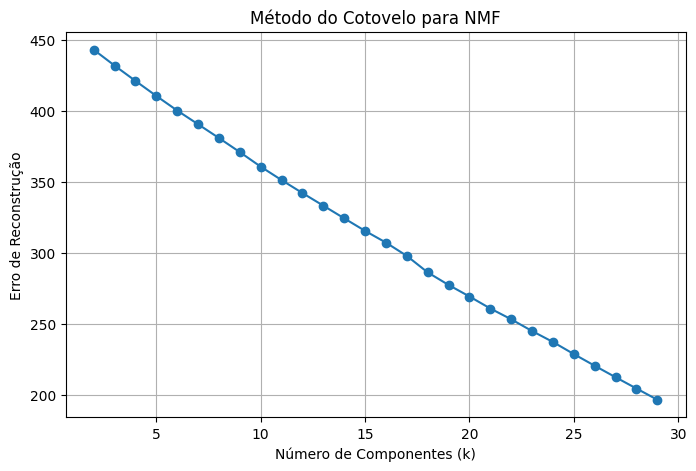

In [ ]:
ks = list(range(2, 30))  # valores de k para testar
errors = []

for k in ks:
    model = NMF(
        n_components=k,
        init="nndsvd",
        random_state=42,
        beta_loss="frobenius",
        #alpha_W=0.1,
        #alpha_H=0.0005,
        #l1_ratio=0.9,
        solver="cd",
        max_iter=2000
    )
    W = model.fit_transform(matriz_lc)
    H = model.components_
    errors.append(model.reconstruction_err_)

# Plotando
plt.figure(figsize=(8, 5))
plt.plot(ks, errors, marker='o')
plt.xlabel("Número de Componentes (k)")
plt.ylabel("Erro de Reconstrução")
plt.title("Método do Cotovelo para NMF")
plt.grid(True)
plt.show()


In [ ]:
model = NMF(
        n_components=44,
        init="nndsvd",
        random_state=42,
        beta_loss="frobenius",
        #alpha_W=0.1,
        #alpha_H=0.0005,
        #l1_ratio=0.9,
        solver="cd",
        max_iter=2000
    )
W = model.fit_transform(matriz_lc)
H = model.components_

In [ ]:
np.set_printoptions(threshold=np.inf, linewidth=np.inf, precision=3, suppress=True)
print(H)
#interpretação: algumas questões, como a primeira, são bem difíceis de acertar. Já a questão 10 é fácil, pois a maior parte dos perfis acerta

[[12.826  0.     0.073  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.    10.359  0.19   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.    19.142  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.009  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.001  0.     0.     0.     0.     0.001  0.001  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.001  0.     0.001  0.   ]
 [ 0.     0.     0.     0.     0.     0.     0

In [ ]:
model = NMF(
        n_components=44,
        init="nndsvd",
        random_state=42,
        beta_loss="frobenius",
        #alpha_W=0.1,
        alpha_H=0.0005,
        l1_ratio=1,
        solver="cd",
        max_iter=2000
    )
W = model.fit_transform(matriz_lc)
H = model.components_

/usr/local/lib/python3.11/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(


In [ ]:
np.set_printoptions(threshold=np.inf, linewidth=np.inf, precision=3, suppress=True)
print(H)

[[0.363 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.241 0.004 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.406 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   

In [ ]:
np.set_printoptions(threshold=np.inf, linewidth=np.inf, precision=3, suppress=True)
print(W)

###Humanas

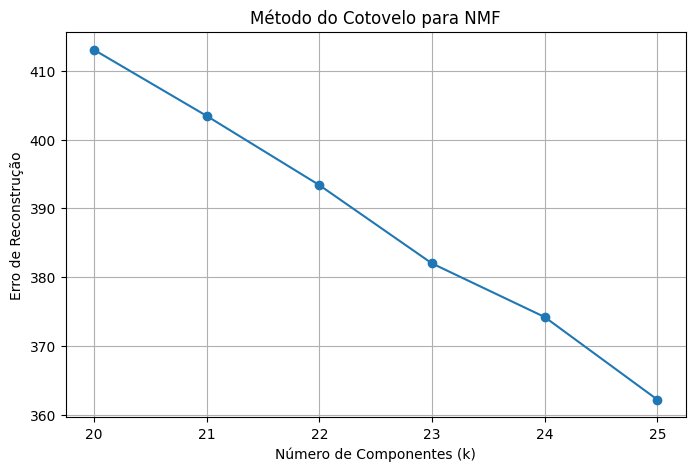

In [ ]:
ks = list(range(20, 26))  # valores de k para testar
errors = []

for k in ks:
    model = NMF(
        n_components=k,
        init="nndsvd",
        random_state=42,
        beta_loss="frobenius",
        #alpha_W=0.1,
        #alpha_H=0.0005,
        #l1_ratio=0.96,
        solver="cd",
        max_iter=1500
    )
    W = model.fit_transform(matriz_ch)
    H = model.components_
    errors.append(model.reconstruction_err_)

# Plotando
plt.figure(figsize=(8, 5))
plt.plot(ks, errors, marker='o')
plt.xlabel("Número de Componentes (k)")
plt.ylabel("Erro de Reconstrução")
plt.title("Método do Cotovelo para NMF")
plt.grid(True)
plt.show()

###Natureza

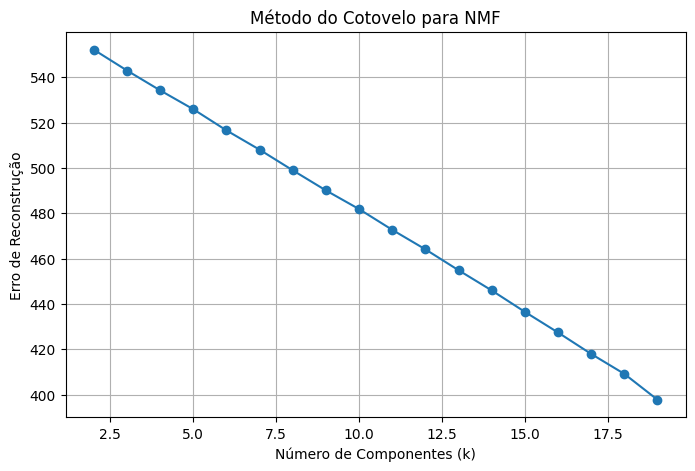

In [ ]:
ks = list(range(2, 20))  # valores de k para testar
errors = []

for k in ks:
    model = NMF(
        n_components=k,
        init="nndsvd",
        random_state=42,
        beta_loss="frobenius",
        #alpha_W=0.1,
        #alpha_H=0.0005,
        #l1_ratio=0.96,
        solver="cd",
        max_iter=2000
    )
    W = model.fit_transform(matriz_cn)
    H = model.components_
    errors.append(model.reconstruction_err_)

# Plotando
plt.figure(figsize=(8, 5))
plt.plot(ks, errors, marker='o')
plt.xlabel("Número de Componentes (k)")
plt.ylabel("Erro de Reconstrução")
plt.title("Método do Cotovelo para NMF")
plt.grid(True)
plt.show()

###Matemática

In [ ]:
ks = list(range(2, 40))  # valores de k para testar
errors = []
np.set_printoptions(precision=3, suppress=True)

for k in ks:
    model = NMF(
        n_components=k,
        init="nndsvd",
        random_state=42,
        beta_loss="frobenius",
        #alpha_W=0.1,
        #alpha_H=0.0005,
        #l1_ratio=0.96,
        solver="cd",
        max_iter=2000
    )
    W = model.fit_transform(matriz_mt)
    H = model.components_
    errors.append(model.reconstruction_err_)

    print(f"\n=== Matriz H para k = {k} ===")
    print(H)

# Plotando
# plt.figure(figsize=(8, 5))
# plt.plot(ks, errors, marker='o')
# plt.xlabel("Número de Componentes (k)")
# plt.ylabel("Erro de Reconstrução")
# plt.title("Método do Cotovelo para NMF")
# plt.grid(True)
# plt.show()


=== Matriz H para k = 2 ===
[[0.438 1.726 2.208 0.558 0.55  0.553 0.81  1.919 1.901 2.723 0.317 1.586 0.493 0.149 0.615 0.82  1.248 0.    2.57  1.93  2.343 0.    0.205 0.811 2.257 0.    2.866 0.    2.178 0.77  2.682 2.477 5.217 0.869 3.431 6.048 3.086 7.244 0.004 7.397 1.348 6.896 0.    6.883 3.255]
 [2.56  2.197 2.096 2.897 2.162 0.522 2.065 2.445 2.422 0.732 2.333 1.943 3.494 4.696 1.471 4.244 1.99  3.933 2.698 2.807 1.707 0.    3.914 2.67  1.945 4.246 2.431 3.334 2.964 2.176 1.785 1.773 1.472 3.064 1.071 0.329 1.513 0.    2.519 1.053 1.212 0.    1.689 1.09  2.258]]

=== Matriz H para k = 3 ===
[[1.18  0.    1.837 0.    0.336 0.    0.    0.906 2.494 1.385 1.086 0.    1.38  0.    0.365 1.67  0.    0.    5.021 1.032 1.219 0.    0.758 0.609 0.978 0.336 5.198 0.691 4.483 2.107 3.381 4.934 3.661 2.642 5.442 3.895 0.    4.772 0.623 2.779 0.405 4.202 0.23  3.002 0.901]
 [2.04  2.257 1.642 2.768 2.015 0.57  1.9   2.206 1.667 0.55  1.757 2.035 2.892 4.643 1.36  3.598 1.882 4.009 0.916 2.584 

KeyboardInterrupt: 

In [ ]:
ks = list(range(30, 45))  # valores de k para testar
errors = []
np.set_printoptions(precision=3, suppress=True)

for k in ks:
    model = NMF(
        n_components=k,
        init="nndsvd",
        random_state=42,
        beta_loss="frobenius",
        #alpha_W=0.1,
        #alpha_H=0.0005,
        #l1_ratio=0.96,
        solver="cd",
        max_iter=200
    )
    W = model.fit_transform(matriz_mt)
    H = model.components_
    errors.append(model.reconstruction_err_)


plt.figure(figsize=(8, 5))
plt.plot(ks, errors, marker='o')
plt.xlabel("Número de Componentes (k)")
plt.ylabel("Erro de Reconstrução")
plt.title("Método do Cotovelo para NMF")
plt.grid(True)
plt.show()

###Para todas as disciplinas

In [ ]:
matriz_geral = np.concatenate([matriz_lc, matriz_ch, matriz_cn, matriz_mt], axis=1)[0:1000, :]

In [ ]:
#decréscimo do erro parece mto linear pra todas as disciplinas - método do cotovelo parece não ser a melhor maneira de avaliar isso

In [ ]:
#fiz a matriz geral para poder analisar H para toda a prova, para tentar identificar, manualmente, o valor de k que retorna a matriz H que melhor determina padrões de alunos - bias: será que é lógico esperar que uma pessoa boa em matemática seja, também, boa em natureza?

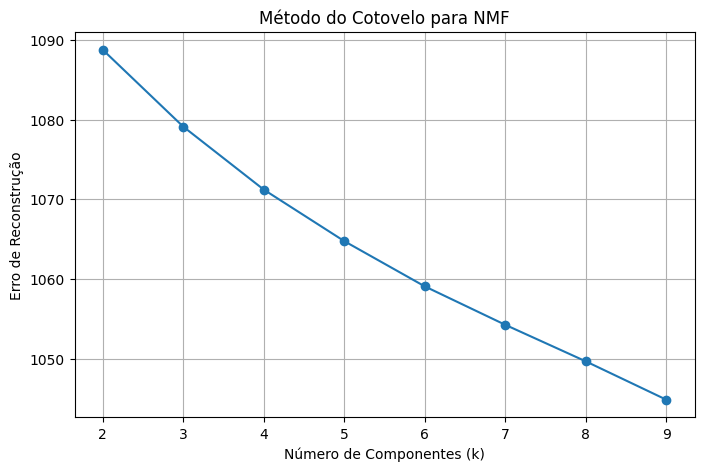

In [ ]:
ks = list(range(2, 10))  # valores de k para testar
errors = []

for k in ks:
    model = NMF(
        n_components=k,
        init="nndsvd",
        random_state=42,
        beta_loss="frobenius",
        #alpha_W=0.1,
        #alpha_H=0.0005,
        #l1_ratio=0.9,
        solver="cd",
        max_iter=2000
    )
    W = model.fit_transform(matriz_geral)
    H = model.components_
    errors.append(model.reconstruction_err_)

# Plotando
plt.figure(figsize=(8, 5))
plt.plot(ks, errors, marker='o')
plt.xlabel("Número de Componentes (k)")
plt.ylabel("Erro de Reconstrução")
plt.title("Método do Cotovelo para NMF")
plt.grid(True)
plt.show()


In [ ]:
ks = list(range(48, 50))  # valores de k para testar
errors = []

for k in ks:
    model = NMF(
        n_components=k,
        init="nndsvd",
        random_state=42,
        beta_loss="frobenius",
        #alpha_W=0.1,
        #alpha_H=0.0005,
        #l1_ratio=0.9,
        solver="cd",
        max_iter=2000
    )
    W = model.fit_transform(matriz_geral)
    H = model.components_
    errors.append(model.reconstruction_err_)

# Plotando
plt.figure(figsize=(8, 5))
plt.plot(ks, errors, marker='o')
plt.xlabel("Número de Componentes (k)")
plt.ylabel("Erro de Reconstrução")
plt.title("Método do Cotovelo para NMF")
plt.grid(True)
plt.show()

KeyboardInterrupt: 

In [ ]:
ks = list(range(100, 102))  # valores de k para testar
errors = []

for k in ks:
    model = NMF(
        n_components=k,
        init="nndsvd",
        random_state=42,
        beta_loss="frobenius",
        #alpha_W=0.1,
        #alpha_H=0.0005,
        #l1_ratio=0.9,
        solver="cd",
        max_iter=2000
    )
    W = model.fit_transform(matriz_geral)
    H = model.components_
    errors.append(model.reconstruction_err_)

# Plotando
plt.figure(figsize=(8, 5))
plt.plot(ks, errors, marker='o')
plt.xlabel("Número de Componentes (k)")
plt.ylabel("Erro de Reconstrução")
plt.title("Método do Cotovelo para NMF")
plt.grid(True)
plt.show()

####mudando de estratégia: visualização

o ponto aqui é: pelos trechos de k que utilizamos jo método do cotovelo, parece que a função que modela essa relação ente o número de componentes e o erro cometido na aproximação é linear. Em consequência, o "melhor" número de componentes seria o maior possível. Isso não fazia muito sentido. Pensei que uma possível explicação poderia ser que não há padrões significativos, ou seja, (a distribuição de erros e acertos seria uniforme?). Pra isso, vou aplicar red dimensionalidade focada na visualização 2D desses dados e ver se há indícios de clusters ou não. A princípio, vou fazer isso com a matriz da prova toda. Caso veja algo promissor, posso replicar o método para as provas separadas

In [ ]:
#distâncias adequadas: cosseno, hamming e sorensen-dice

In [ ]:
pip install scikit-learn openTSNE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.0 MB/s eta 0:00:00


In [ ]:
pip install scipy

In [ ]:
from sklearn.decomposition import TruncatedSVD, PCA
from openTSNE import TSNE
import matplotlib.pyplot as plt
from sklearn.preprocessing import Normalizer
from sklearn.metrics import pairwise_distances

In [ ]:
#SVD truncado até 90 componentes + OpenTSNE até 2 com métrica cosseno

In [ ]:
svd = TruncatedSVD(n_components=90, random_state=42)
M_svd = svd.fit_transform(matriz_geral)

In [ ]:
M_svd = Normalizer().fit_transform(M_svd)

In [ ]:
tsne = TSNE(
    n_components=2,
    metric="cosine",
    perplexity=50,
    n_jobs=-1,
    random_state=42
)
M_tsne = tsne.fit(M_svd)

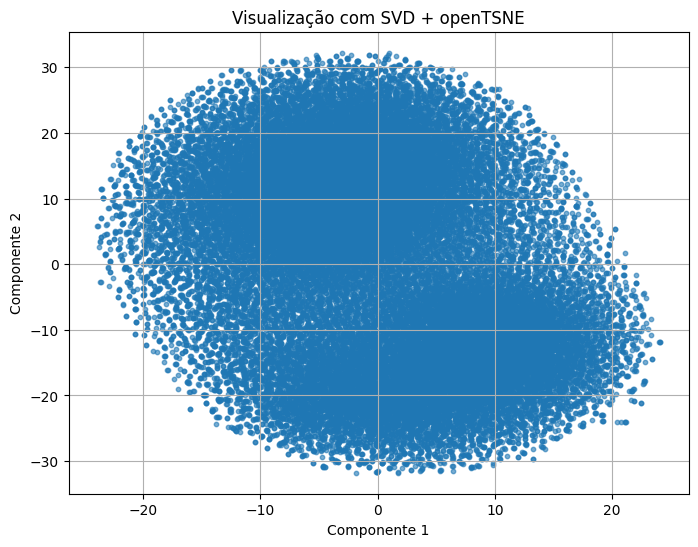

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(M_tsne[:, 0], M_tsne[:, 1], s=10, alpha=0.6)
plt.title("Visualização com SVD + openTSNE")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

meio uniforme + 2 possíveis grupões linearmente separáveis (?) - tem k=2

In [ ]:
#OpenTSNE até 2 com métrica hamming

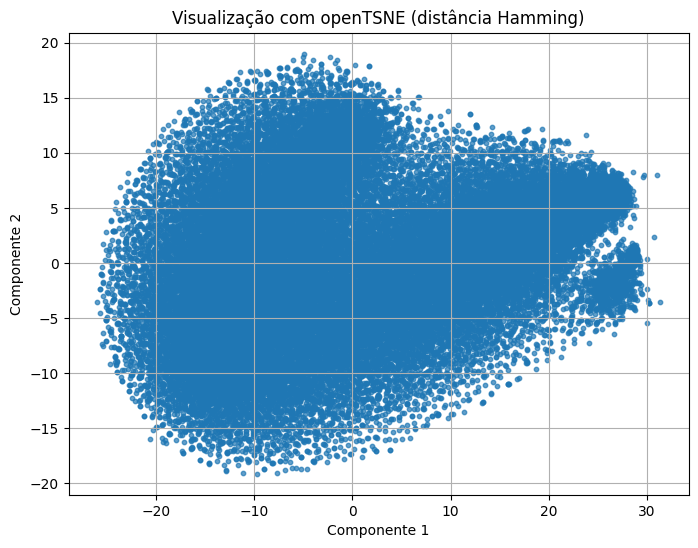

In [ ]:
tsne = TSNE(
    n_components=2,
    metric="hamming",
    perplexity=50,
    n_jobs=-1,
    random_state=42
)

M_tsne = tsne.fit(matriz_geral)

plt.figure(figsize=(8, 6))
plt.scatter(M_tsne[:, 0], M_tsne[:, 1], s=10, alpha=0.7)
plt.title("Visualização com openTSNE (distância Hamming)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

não parece ter nada

In [ ]:
##OpenTSNE até 2 com métrica dice

In [ ]:
#crush por RAM - abandonei
distance_matrix = pairwise_distances(matriz_geral, metric='dice')
tsne = TSNE(
    n_components=2,
    metric="precomputed",
    perplexity=50,
    n_jobs=-1,
    random_state=42
)
M_tsne = tsne.fit(distance_matrix)


plt.figure(figsize=(8, 6))
plt.scatter(M_tsne[:, 0], M_tsne[:, 1], s=10, alpha=0.7)
plt.title("openTSNE com distância Sørensen-Dice (dados binários)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric dice
  warnings.warn(msg, DataConversionWarning)


In [ ]:
#SVD truncado até 18 componentes + tsne distância cosseno

In [ ]:
svd = TruncatedSVD(n_components=18, random_state=42)
M_svd = svd.fit_transform(matriz_geral)

In [ ]:
M_svd = Normalizer().fit_transform(M_svd)

In [ ]:
tsne = TSNE(
    n_components=2,
    metric="cosine",
    perplexity=50,
    n_jobs=-1,
    random_state=42
)
M_tsne = tsne.fit(M_svd)

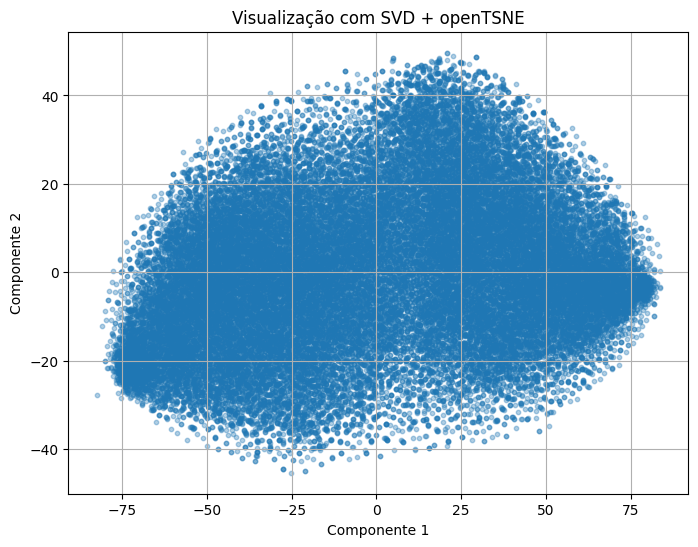

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(M_tsne[:, 0], M_tsne[:, 1], s=10, alpha=0.35)
plt.title("Visualização com SVD + openTSNE")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

será que é sugestivo para fazer para cada prova?

In [ ]:
#para cada prova

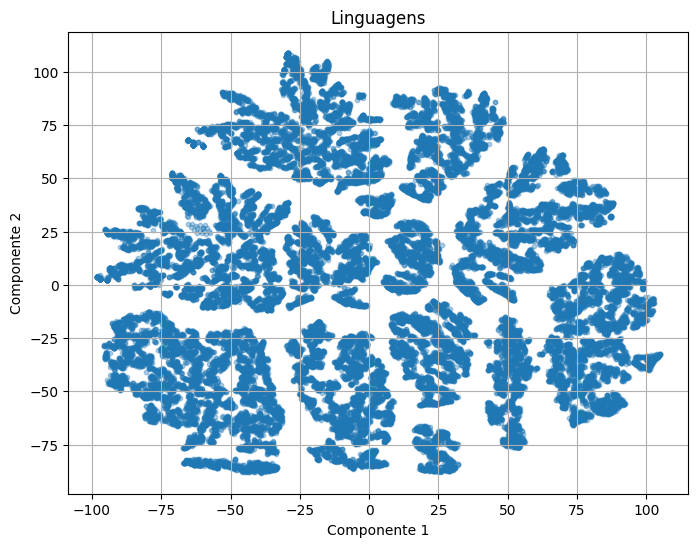

In [ ]:
#linguagens
svd = TruncatedSVD(n_components=5, random_state=42)
M_svd = svd.fit_transform(matriz_lc)
M_svd = Normalizer().fit_transform(M_svd)
tsne = TSNE(
    n_components=2,
    metric="cosine",
    perplexity=50,
    n_jobs=-1,
    random_state=42
)
M_tsne = tsne.fit(M_svd)

plt.figure(figsize=(8, 6))
plt.scatter(M_tsne[:, 0], M_tsne[:, 1], s=10, alpha=0.35)
plt.title("Linguagens")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

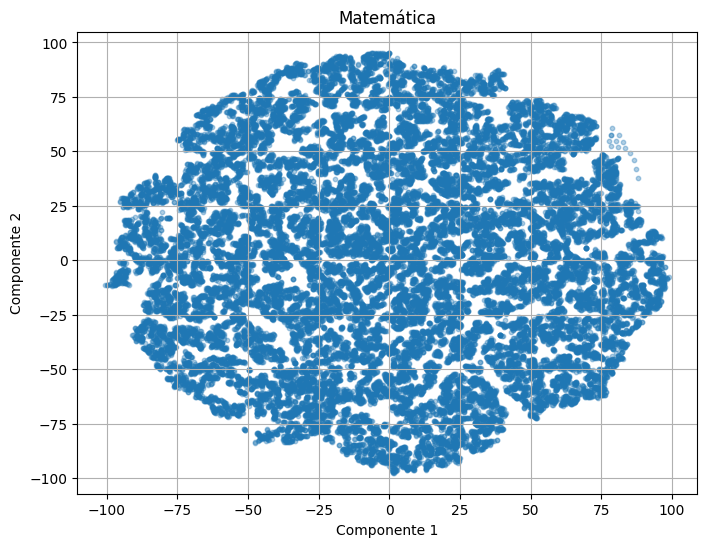

In [ ]:
#linguagens
svd = TruncatedSVD(n_components=5, random_state=42)
M_svd = svd.fit_transform(matriz_mt)
M_svd = Normalizer().fit_transform(M_svd)
tsne = TSNE(
    n_components=2,
    metric="cosine",
    perplexity=50,
    n_jobs=-1,
    random_state=42
)
M_tsne = tsne.fit(M_svd)

plt.figure(figsize=(8, 6))
plt.scatter(M_tsne[:, 0], M_tsne[:, 1], s=10, alpha=0.35)
plt.title("Matemática")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

In [ ]:
#linguagens
svd = TruncatedSVD(n_components=5, random_state=42)
M_svd = svd.fit_transform(matriz_cn)
M_svd = Normalizer().fit_transform(M_svd)
tsne = TSNE(
    n_components=2,
    metric="cosine",
    perplexity=50,
    n_jobs=-1,
    random_state=42
)
M_tsne = tsne.fit(M_svd)

plt.figure(figsize=(8, 6))
plt.scatter(M_tsne[:, 0], M_tsne[:, 1], s=10, alpha=0.35)
plt.title("Ciências")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

In [ ]:
#linguagens
svd = TruncatedSVD(n_components=5, random_state=42)
M_svd = svd.fit_transform(matriz_ch)
M_svd = Normalizer().fit_transform(M_svd)
tsne = TSNE(
    n_components=2,
    metric="cosine",
    perplexity=50,
    n_jobs=-1,
    random_state=42
)
M_tsne = tsne.fit(M_svd)

plt.figure(figsize=(8, 6))
plt.scatter(M_tsne[:, 0], M_tsne[:, 1], s=10, alpha=0.35)
plt.title("Humanas")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

####SVD

In [ ]:
matriz_sec = np.concatenate([matriz_ch, matriz_cn, matriz_mt], axis=1)

In [ ]:
matriz_sec

array([[1, 1, 1, ..., 0, 1, 0],
       [0, 1, 1, ..., 0, 1, 0],
       [1, 0, 1, ..., 0, 1, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 1],
       [0, 1, 1, ..., 0, 0, 1],
       [1, 0, 0, ..., 0, 1, 1]])

In [ ]:
matriz_sec.shape

(20000, 135)

In [ ]:
# errors = []
# svd = TruncatedSVD(n_components=20, random_state=42)
# M_svd = svd.fit_transform(matriz_sec)

U, S, vt = np.linalg.svd(matriz_sec)
eigenvalues = S**2

plt.figure(figsize=(8, 6))
plt.plot(eigenvalues, marker='o')
plt.xlabel("Componente")
plt.ylabel("Valor do Autovalor")
plt.title("Ciências")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

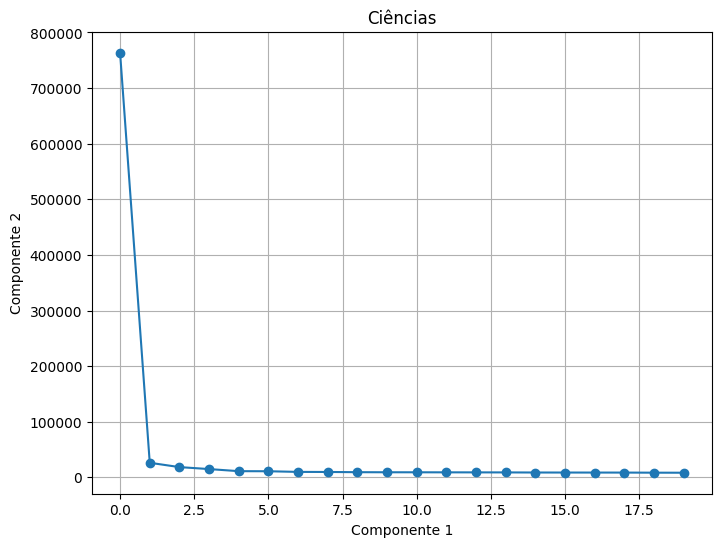

In [ ]:
svd = TruncatedSVD(n_components=20, random_state=42)
M_svd = svd.fit_transform(matriz_sec)

eigenvalues_truncated = svd.singular_values_**2

plt.figure(figsize=(8, 6))
plt.plot(eigenvalues_truncated, marker='o')
plt.xlabel("Componente")
plt.ylabel("Valor do Autovalor")
plt.title("Ciências")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

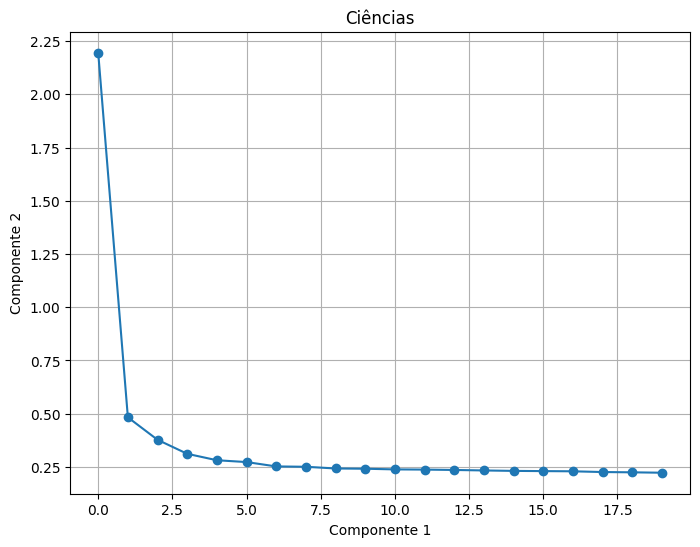

In [ ]:
pca = PCA(n_components=20, random_state=42)
pca.fit_transform(matriz_sec)

eigenvalues_truncated = pca.explained_variance_

plt.figure(figsize=(8, 6))
plt.plot(eigenvalues_truncated, marker='o')
plt.xlabel("Componente")
plt.ylabel("Valor do Autovalor")
plt.title("Ciências")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

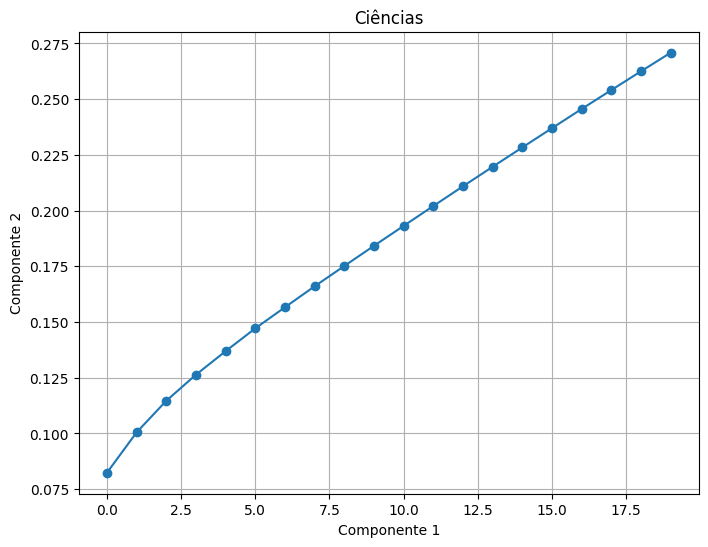

In [ ]:
pca = PCA(n_components=20, random_state=42)
pca.fit_transform(matriz_sec)

cum_var=np.cumsum(pca.explained_variance_ratio_)


plt.figure(figsize=(8, 6))
plt.plot(cum_var, marker='o')
plt.xlabel("Componente")
plt.ylabel("Valor do Autovalor")
plt.title("Ciências")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

In [ ]:
matriz_chmt = np.concatenate([matriz_ch, matriz_mt], axis=1)

In [ ]:
matriz_chmt = matriz_chmt[np.sum(matriz_chmt, axis=1) >= 70]


In [ ]:
matriz_chmt.shape

(191, 90)

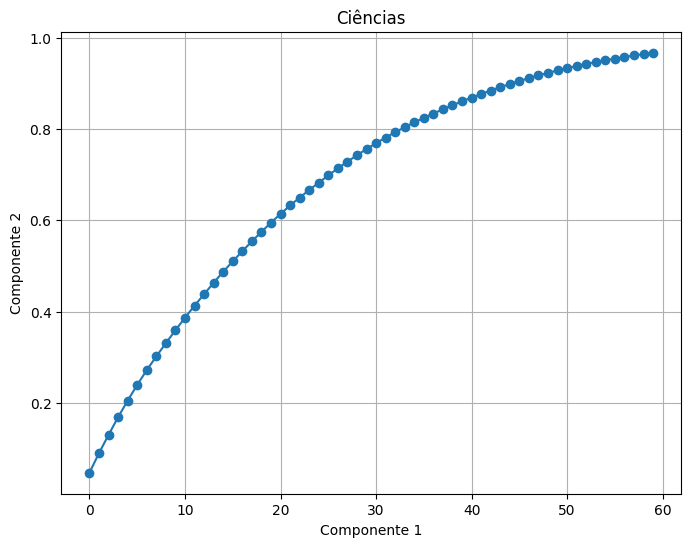

In [ ]:
pca = PCA(n_components=60, random_state=42)
pca.fit_transform(matriz_chmt)

cum_var=np.cumsum(pca.explained_variance_ratio_)


plt.figure(figsize=(8, 6))
plt.plot(cum_var, marker='o')
plt.xlabel("Componente")
plt.ylabel("Valor do Autovalor")
plt.title("Ciências")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()